# The Sigmoid Function (and its Derivative)

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on the **sigmoid function**
(Week 3 — Optimization in Neural Networks and Newton's Method).

This notebook explains:

- the sigmoid $\sigma(z) = \dfrac{1}{1+e^{-z}}$, its graph, asymptotes, and key values
- why we care so much about its **derivative**
- a step-by-step derivation that
  $\sigma'(z) = \sigma(z)\big(1-\sigma(z)\big)$
- a SymPy proof and a numerical check
- plots of the sigmoid alongside its derivative

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*Classification with a Perceptron*.

## 1. Recap: the sigmoid function

The sigmoid takes the **entire number line** and crunches it into the interval $(0, 1)$ —
exactly what we want for a classification output:

$$
\sigma(z) = \frac{1}{1 + e^{-z}} .
$$

- The input ($z$) is the horizontal axis; the output is the vertical axis in $(0,1)$.
- It has **asymptotes** at $0$ and $1$: it never quite reaches them, but every $z$ maps
  strictly between.
- $\sigma(0) = \dfrac{1}{1+e^{0}} = \dfrac{1}{1+1} = \dfrac12$.
- $\sigma(1000) \approx 1$ and $\sigma(-1000) \approx 0$.

σ( -1000) = 0.000000
σ(    -2) = 0.119203
σ(     0) = 0.500000
σ(     2) = 0.880797
σ(  1000) = 1.000000


/var/folders/1b/v9408tps52n06ptkrvhd1pdh0000gn/T/ipykernel_60912/3069872373.py:6: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


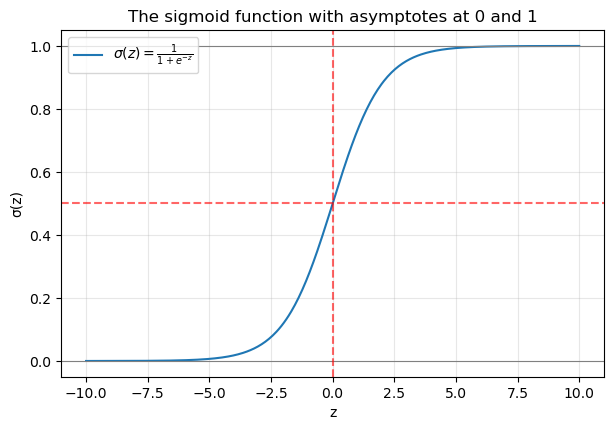

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

for z in [-1000, -2, 0, 2, 1000]:
    print(f"σ({z:>6}) = {sigmoid(np.float64(z)):.6f}")

zz = np.linspace(-10, 10, 400)
plt.figure(figsize=(7, 4.5))
plt.plot(zz, sigmoid(zz), label=r"$\sigma(z)=\frac{1}{1+e^{-z}}$")
plt.axhline(0, color="gray", lw=0.8); plt.axhline(1, color="gray", lw=0.8)
plt.axhline(0.5, color="red", ls="--", alpha=0.6)
plt.axvline(0, color="red", ls="--", alpha=0.6)
plt.title("The sigmoid function with asymptotes at 0 and 1")
plt.xlabel("z"); plt.ylabel("σ(z)")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 2. Why the derivative matters

> *"In machine learning we're going to use derivatives a lot, so it's very important that a
> function is easy to differentiate."*

Training (gradient descent) needs the derivative of the activation. The sigmoid's
derivative turns out to be remarkably clean — which is a big reason the sigmoid is so
popular.

## 3. Deriving $\sigma'(z)$ step by step

Write the sigmoid with a negative exponent:

$$
\sigma(z) = \big(1 + e^{-z}\big)^{-1} .
$$

**Chain rule** on the outer power $(\cdot)^{-1}$:

$$
\sigma'(z) = -1\cdot\big(1 + e^{-z}\big)^{-2}\cdot \frac{d}{dz}\big(1 + e^{-z}\big).
$$

The inside derivative is $\dfrac{d}{dz}(1 + e^{-z}) = 0 + e^{-z}\cdot(-1) = -e^{-z}$.
The two minus signs cancel:

$$
\sigma'(z) = \frac{e^{-z}}{\big(1 + e^{-z}\big)^{2}} .
$$

**The add-and-subtract-1 trick.** Write $e^{-z} = \big(1 + e^{-z}\big) - 1$ in the
numerator and split the fraction:

$$
\sigma'(z) = \frac{(1+e^{-z}) - 1}{(1+e^{-z})^{2}}
= \frac{1}{1+e^{-z}} - \frac{1}{(1+e^{-z})^{2}}
= \frac{1}{1+e^{-z}}\left(1 - \frac{1}{1+e^{-z}}\right).
$$

Both factors are the sigmoid itself, so

$$
\boxed{\;\sigma'(z) = \sigma(z)\,\big(1 - \sigma(z)\big).\;}
$$

> *"Isn't that beautiful? The derivative of sigmoid is sigmoid times one minus sigmoid."*

## 4. Verifying with SymPy

In [2]:
z = sp.symbols('z')
sig = 1 / (1 + sp.exp(-z))

deriv = sp.diff(sig, z)
nice  = sig * (1 - sig)

print("SymPy derivative          :", sp.simplify(deriv))
print("σ(1-σ) minus the derivative:", sp.simplify(deriv - nice), " (0 confirms equality)")

SymPy derivative          : 1/(4*cosh(z/2)**2)
σ(1-σ) minus the derivative: 0  (0 confirms equality)


## 5. Numerical check

A central finite difference should match $\sigma(z)\,(1-\sigma(z))$.

In [3]:
def dsigmoid(z):
    s = sigmoid(z)
    return s * (1 - s)

def numeric_deriv(f, z, h=1e-6):
    return (f(z + h) - f(z - h)) / (2 * h)

print(f"{'z':>5} | {'numeric':>10} | {'σ(1-σ)':>10}")
for z0 in [-3.0, -1.0, 0.0, 1.0, 3.0]:
    print(f"{z0:>5.1f} | {numeric_deriv(sigmoid, z0):>10.6f} | {dsigmoid(z0):>10.6f}")

    z |    numeric |     σ(1-σ)
 -3.0 |   0.045177 |   0.045177
 -1.0 |   0.196612 |   0.196612
  0.0 |   0.250000 |   0.250000
  1.0 |   0.196612 |   0.196612
  3.0 |   0.045177 |   0.045177


## 6. The sigmoid and its derivative

The derivative is a **bell shape**, largest where the sigmoid is steepest ($z=0$, value
$0.25$) and tiny in the flat tails.

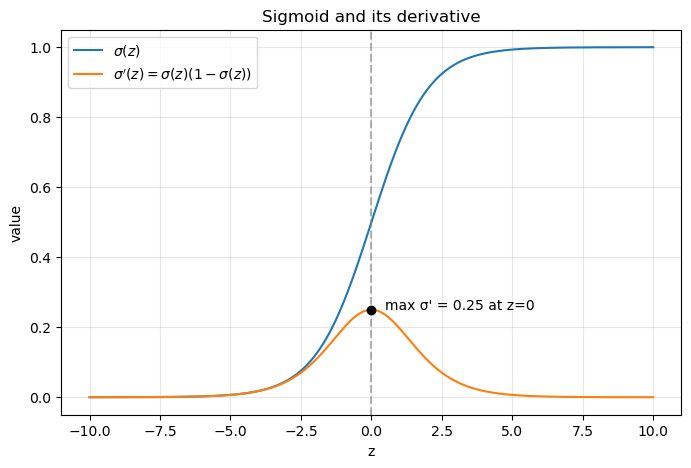

In [4]:
zz = np.linspace(-10, 10, 400)

plt.figure(figsize=(8, 5))
plt.plot(zz, sigmoid(zz), label=r"$\sigma(z)$")
plt.plot(zz, dsigmoid(zz), label=r"$\sigma'(z)=\sigma(z)(1-\sigma(z))$")
plt.axvline(0, color="gray", ls="--", alpha=0.6)
plt.plot(0, dsigmoid(0), "ko")
plt.annotate(f"max σ' = {dsigmoid(0):.2f} at z=0", (0, dsigmoid(0)),
             textcoords="offset points", xytext=(10, 0))
plt.title("Sigmoid and its derivative")
plt.xlabel("z"); plt.ylabel("value")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 7. Exercises

### Basic
1. Write the sigmoid function and its output range.
2. What is $\sigma(0)$, and why?

### Intermediate
3. State the derivative of the sigmoid in terms of $\sigma$.
4. Compute $\sigma'(0)$ and explain why it is the maximum value of the derivative.

### Advanced
5. Using the add-and-subtract-1 trick, re-derive $\sigma'(z) = \sigma(z)(1-\sigma(z))$ from
   $\dfrac{e^{-z}}{(1+e^{-z})^2}$.
6. The derivative is tiny when $|z|$ is large. Explain what this implies for training
   (the "vanishing gradient" intuition).

## 8. Solutions / Checks

In [5]:
z = sp.symbols('z')
sig = 1 / (1 + sp.exp(-z))

print("2. σ(0) =", sig.subs(z, 0), " because 1/(1+e^0)=1/2")
print("3. σ'(z) = σ(z)(1-σ(z)); SymPy:", sp.simplify(sp.diff(sig, z) - sig*(1-sig)), "= 0 ✓")
print("4. σ'(0) =", float(dsigmoid(0)), "= 0.25; it's the max because σ is steepest at z=0.")
print("6. Large |z| -> σ'(z) ≈ 0, so gradients nearly vanish and learning stalls "
      "in the saturated tails (vanishing gradients).")

2. σ(0) = 1/2  because 1/(1+e^0)=1/2
3. σ'(z) = σ(z)(1-σ(z)); SymPy: 0 = 0 ✓
4. σ'(0) = 0.25 = 0.25; it's the max because σ is steepest at z=0.
6. Large |z| -> σ'(z) ≈ 0, so gradients nearly vanish and learning stalls in the saturated tails (vanishing gradients).


## 9. Conclusion

- The sigmoid $\sigma(z) = \dfrac{1}{1+e^{-z}}$ maps $\mathbb{R}$ into $(0,1)$ with
  asymptotes at $0$ and $1$ and $\sigma(0) = \tfrac12$.
- Its derivative is exceptionally clean:

$$
\sigma'(z) = \sigma(z)\,\big(1 - \sigma(z)\big),
$$

computable directly from the sigmoid's own value — no re-evaluation of exponentials.
- This easy derivative is why the sigmoid is so convenient in **gradient-descent training**
  of classifiers and neural networks.
- The derivative peaks at $0.25$ ($z=0$) and vanishes in the tails — a hint of the
  vanishing-gradient issue in deep networks.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/opt_nns_5.mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 3) lecture on the **sigmoid function**. Key spoken points, lightly cleaned:

> The sigmoid crunches the entire number line into $(0,1)$, which is what we want for the
> output. Its formula is $1/(1+e^{-z})$; the input is the horizontal axis and the output
> the vertical, with asymptotes at 0 and 1 that it never quite touches. $\sigma(0)=1/2$,
> $\sigma(1000)\approx 1$, $\sigma(-1000)\approx 0$. Beyond squashing, the sigmoid has a
> very nice derivative — important because machine learning uses derivatives a lot. Writing
> $\sigma = (1+e^{-z})^{-1}$ and applying the chain rule gives
> $-1\,(1+e^{-z})^{-2}\cdot(-e^{-z}) = e^{-z}/(1+e^{-z})^2$. Rewriting $e^{-z}$ as
> $(1+e^{-z}) - 1$ and splitting the fraction yields
> $\frac{1}{1+e^{-z}} - \frac{1}{(1+e^{-z})^2} = \sigma - \sigma^2$, i.e.
> $\sigma'(z) = \sigma(z)(1-\sigma(z))$. This easy derivative makes the sigmoid very useful
> in machine learning.